In [ ]:
# Import Libraries

In [ ]:
import tensorflow as tf # Import the TensorFlow library for building and training neural networks

from tensorflow.keras.datasets import mnist # Import the MNIST dataset from Keras

from tensorflow.keras.models import Sequential # Import Sequential model for building a linear stack of layers

from tensorflow.keras.layers import Conv2D # Import Conv2D layer for 2D convolution operations
from tensorflow.keras.layers import MaxPooling2D # Import MaxPooling2D layer for 2D max pooling operations
from tensorflow.keras.layers import Flatten # Import Flatten layer to convert 2D data to 1D for dense layers
from tensorflow.keras.layers import Dense # Import Dense layer for fully connected neural network layers

import matplotlib.pyplot as plt # Import Matplotlib for plotting and visualization

**Load Dataset**

In [ ]:
# Load the MNIST dataset, splitting it into training and testing sets
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


**Check Dataset Shape**

In [ ]:
print(X_train.shape) # Print the shape of the training data (number of samples, height, width)

print(X_test.shape) # Print the shape of the testing data (number of samples, height, width)

(60000, 28, 28)
(10000, 28, 28)


**Display First Image**

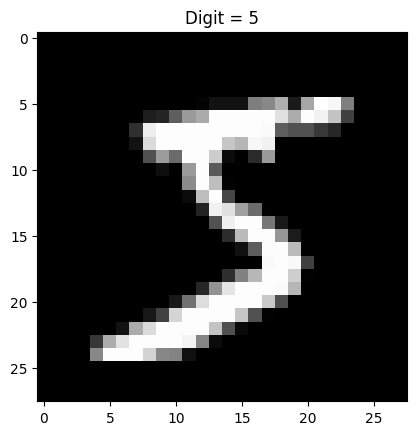

In [ ]:
plt.imshow(X_train[0], cmap="gray") # Display the first image from the training set in grayscale

plt.title(f"Digit = {y_train[0]}") # Set the title of the plot to show the actual digit label

plt.show() # Show the plot

**Normalize Images**

In [ ]:
X_train = X_train / 255.0 # Normalize the training image pixel values to be between 0 and 1

X_test = X_test / 255.0 # Normalize the testing image pixel values to be between 0 and 1

**Reshape Images**

In [ ]:
X_train = X_train.reshape(-1,28,28,1) # Reshape the training data to add a channel dimension (for grayscale images)

X_test = X_test.reshape(-1,28,28,1) # Reshape the testing data to add a channel dimension

In [ ]:
print(X_train.shape) # Print the new shape of the reshaped training data

(60000, 28, 28, 1)


**Build CNN Model**

In [ ]:
model = Sequential() # Initialize a Sequential model

model.add( # Add a convolutional layer
    Conv2D( # 2D Convolutional Layer
        32, # 32 filters
        (3,3), # 3x3 kernel size
        activation="relu", # ReLU activation function
        input_shape=(28,28,1) # Input shape for the first layer (height, width, channels)
    )
)

model.add( # Add a max pooling layer
    MaxPooling2D( # 2D Max Pooling Layer
        pool_size=(2,2) # 2x2 pool size
    )
)

model.add( # Add another convolutional layer
    Conv2D( # 2D Convolutional Layer
        64, # 64 filters
        (3,3), # 3x3 kernel size
        activation="relu" # ReLU activation function
    )
)

model.add( # Add another max pooling layer
    MaxPooling2D( # 2D Max Pooling Layer
        pool_size=(2,2) # 2x2 pool size
    )
)

model.add( # Add a flatten layer
    Flatten() # Flatten the output of the convolutional layers into a 1D vector
)

model.add( # Add a dense (fully connected) layer
    Dense( # Dense Layer
        128, # 128 units (neurons)
        activation="relu" # ReLU activation function
    )
)

model.add( # Add the output dense layer
    Dense( # Dense Layer
        10, # 10 units (for 10 classes of digits 0-9)
        activation="softmax" # Softmax activation for multi-class classification
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**View Model Summary**

In [ ]:
model.summary() # Print a summary of the model architecture, including layer types, output shapes, and number of parameters

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

**Compile Model**

In [ ]:
model.compile( # Configure the model for training

    optimizer="adam", # Use the Adam optimizer

    loss="sparse_categorical_crossentropy", # Use sparse categorical crossentropy as the loss function (for integer labels)

    metrics=["accuracy"] # Monitor accuracy during training
)

**Train Model**

In [ ]:
history = model.fit( # Train the model

    X_train, # Training input data

    y_train, # Training target labels

    epochs=5, # Train for 5 epochs

    validation_split=0.2 # Use 20% of the training data for validation
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 54s 35ms/step - accuracy: 0.9546 - loss: 0.1500 - val_accuracy: 0.9841 - val_loss: 0.0552
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 78s 32ms/step - accuracy: 0.9846 - loss: 0.0476 - val_accuracy: 0.9879 - val_loss: 0.0413
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 84s 33ms/step - accuracy: 0.9900 - loss: 0.0325 - val_accuracy: 0.9877 - val_loss: 0.0424
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 53s 35ms/step - accuracy: 0.9927 - loss: 0.0227 - val_accuracy: 0.9879 - val_loss: 0.0419
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 32ms/step - accuracy: 0.9940 - loss: 0.0172 - val_accuracy: 0.9890 - val_loss: 0.0423


KeyboardInterrupt: 

**Evaluate Model**

In [ ]:
loss, accuracy = model.evaluate( # Evaluate the trained model on the test dataset

    X_test, # Test input data

    y_test # Test target labels
)

print("Accuracy =", accuracy) # Print the calculated accuracy

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9898 - loss: 0.0339
Accuracy = 0.989799976348877


**Predict**

In [ ]:
prediction = model.predict( # Make predictions on the test dataset

    X_test # Test input data
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


**Predicted Digit**

In [ ]:
import numpy as np # Import the NumPy library for numerical operations

predicted_digit = np.argmax( # Find the index of the maximum value in the prediction array, which corresponds to the predicted digit

    prediction[0] # Get the prediction for the first test image
)

print(predicted_digit) # Print the predicted digit

7


**Compare**

In [ ]:
print("Actual =", y_test[0]) # Print the actual digit from the test set

print("Predicted =", predicted_digit) # Print the predicted digit

Actual = 7
Predicted = 7


**Visualize Prediction**

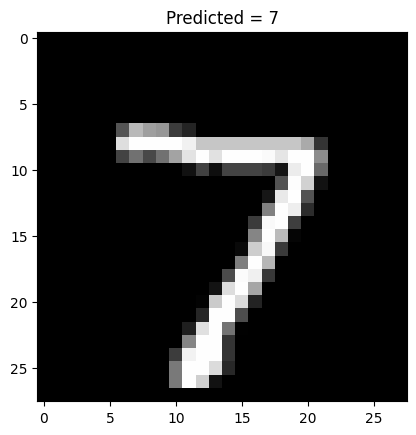

In [ ]:
plt.imshow( # Display the image

    X_test[0].reshape(28,28), # Reshape the first test image back to 28x28 for display

    cmap="gray" # Display in grayscale
)

plt.title(f"Predicted = {predicted_digit}") # Set the title to show the predicted digit

plt.show() # Show the plot